# HMM-GLM Fitting for any number of states
This jupyter notebook is a template for fitting a Generalized Linear Model with Hidden Markov Model (HMM-GLM) to behavioral data, for any given number of states

In [1]:
import sys
import os
import pickle
import ssm

# Make sure we're adding the root of Project_monkey
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now this should work
#from Behaviour.scripts_beh import preprocessing_hmm_glm
from Behaviour.scripts_beh.preprocessing_hmm_glm import *
from Behaviour.scripts_beh.visulaization_hmm_fitting import *
from Behaviour.scripts_beh.fit_hmm_glm_and_predictive_states_extraction import *


### Define the parameters for the HMM-GLM model

In [2]:
# paramters of the model
num_states = 3 # Number of states in the HMM-GLM
obs_dim = 1 # Dimension of the observation (e.g., 1 for binary choice)
num_iters = 1500 # Number of iterations for fitting the model
tolerance = 1e-4 # Tolerance for convergence, standard value
observations = "input_driven_obs" # Type of observations, can be modified
transitions = "standard" # Type of transitions, can be modified


### Define the inputs that you would like to use for the HMM-GLM fitting and will be the regressors of HMM-GLM

In [3]:
# From the data select the regressors we would like to include in the inpts, can be modified accordingly
# This will determine the dimension of the inputs

feature_names = [
            'color', 'direction', 'p_color', 'dist_prev_current_color',
            'p_direction', 'dist_prev_current_motion', 'prev_response', 'intercept'
        ]

### The function below will load the data and prepare the inputs for the HMM-GLM fitting

In [4]:
data_path = os.path.join("..", "..", "Data", "sample_data.pkl")
inpts, choices, data = load_and_prepare_glmhmm_inputs(data_path, feature_names)

### Initilizing & fitting the HMM-GLM model

In [9]:
model = define_glmhmm_model(inpts, num_states=num_states,obs_dim=obs_dim,observations=observations, transitions= transitions)

In [5]:
# Fit the model
model , fit_ll = fit_glmhmm(
    inpts=inpts,
    choices= choices,
    num_states= num_states ,
    obs_dim= obs_dim,
    num_iters= num_iters,
    tolerance= tolerance,
)

  0%|          | 0/1500 [00:00<?, ?it/s]

In [7]:
# Let's extrcat and store the summary of the fitted model, if later we want to reuse it

summary = extract_glmhmm_summary(
    inpts=inpts,
    choices=choices,
    num_states=num_states,  
    filename="summary_hmmglm_model.pkl"
)

# Access components
recovered_weights= summary["glm_weights"]  # GLM regressors for each state
recovered_trans_mat  = summary["transition_matrix"] # Transition probbailities between the states
posterior_probs = summary["posterior_probs"] #  Posterior distribution of the states given the inputs and choices


[INFO] GLM-HMM summary saved in the folder results.


In [8]:
# Snippet to use if the model has already stored paramters and we want to reconstruct the HMM-GLM

model, summary = rebuild_glmhmm_from_summary("summary_hmmglm_model.pkl")

# Access components
recovered_weights= summary["glm_weights"] # GLM regressors for each state
recovered_trans_mat  = summary["transition_matrix"] # Transition probbailities between the states
posterior_probs = summary["posterior_probs"] #  Posterior distribution of the states given the inputs and choices



[INFO] GLM-HMM model rebuilt from summary


### The following functions will visualize the results of the HMM-GLM fitting

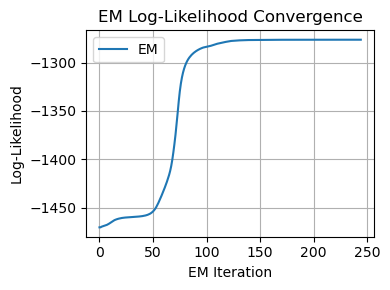

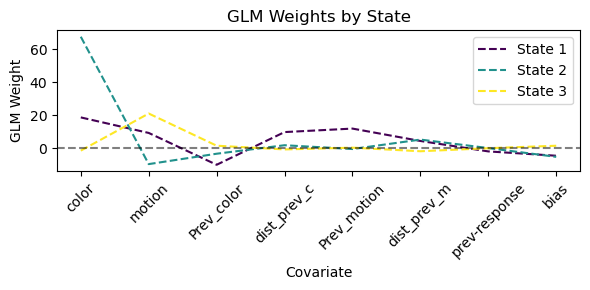

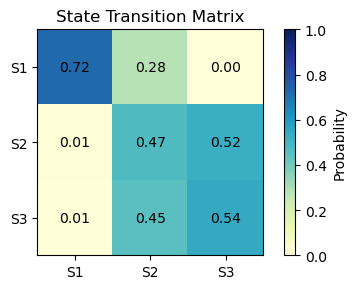

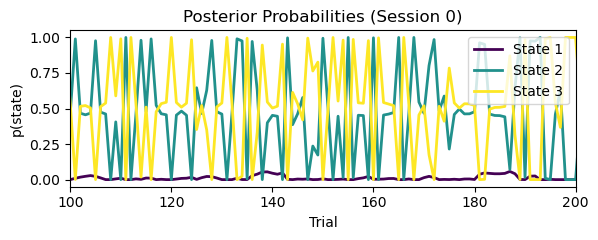

In [6]:
# Visualize for any number of states the log likelihood of the model, the GLM weights, the transition matrix and the posterior probabilities

plot_log_likelihood(fit_ll)
plot_glm_weights(model, regressor_labels=['color', 'motion', 'Prev_color', 'dist_prev_c', 'Prev_motion', 'dist_prev_m', 'prev-response', 'bias'])
plot_transition_matrix(model)
plot_posterior_probs(model, inpts, choices, sess_id=0, trial_window =(100,200))